In [2]:
# Tutorial https://einops.rocks/1-einops-basics/

import numpy as np


from utils import display_np_arrays_as_images # This is a helper implemented in the local utils module

display_np_arrays_as_images()

In [3]:
ims = np.load("./resources/test_images.npy", allow_pickle=False)
print(ims.shape, ims.dtype)

(6, 96, 96, 3) float64


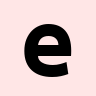

In [3]:
ims[0]

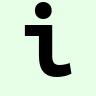

In [5]:
ims[1]

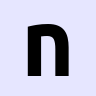

In [6]:
ims[2]

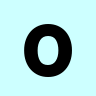

In [7]:
ims[3]

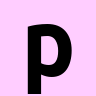

In [8]:
ims[4]

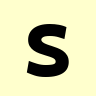

In [9]:
ims[5]

In [4]:
from einops import rearrange, reduce, repeat

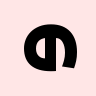

In [ ]:
# We can label each dimension and use -> to specify the output dimensions using the same labels
# swapping the first two dimensions results in transposing the first two axes
# which has the effect of rotating and flipping the image
rearrange(ims[0], "h w c -> w h c")

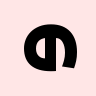

In [8]:
# Labels are arbitrary
rearrange(ims[0], "height width color -> width height color")


## Composition of axes

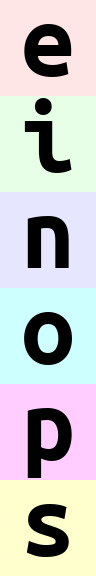

In [16]:
# Collapse the batch and height dimensions into a single dimension, collapsing the 4d tensor to 3d
# Essentially stacking the images into a single image with height b * h
rearrange(ims, "b h w c -> (b h) w c")

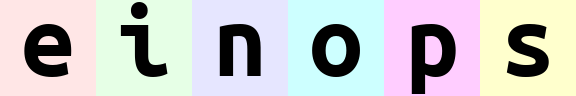

In [18]:
# Now compose batch and width into a new dimension
# Images are stacked horizontally into a single image of width b * w
rearrange(ims, "b h w c -> h (b w) c")

In [ ]:
# Collapse (6, 96, 96 3) to (96, 6 * 96, 3)
rearrange(ims, "b h w c -> h (b w) c").shape

(96, 576, 3)

In [22]:
# We can compose more than 2 axes
# Here we flatten the array
rearrange(ims, "b h w c -> (b h w c)").shape

(165888,)

## Decomposition of axes

In [ ]:
# We can represent as a single dimension on the left hand side as decomposed group of multiple
# components, then use these components to decompose the dimension in the right hand side

# Here we decompose the batch dimension into b1 and b2. einops cannot infer
# the sizes of b1 and b2, so we specify b1=2 and einops infers that b2 = 3.
# This effectively splits a batch of 6 images into 2 batches of 3 images each.

rearrange(ims, "(b1 b2) h w c -> b1 b2 h w c", b1=2).shape

(2, 3, 96, 96, 3)

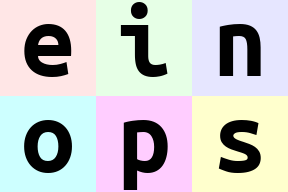

In [25]:
# We can combine composition and decomposition
# Here we split the batch in two, then stack the two batches vertically into a single
# image of height h * b1 and width w * b2

rearrange(ims, "(b1 b2) h w c -> (b1 h) (b2 w) c", b1=2)

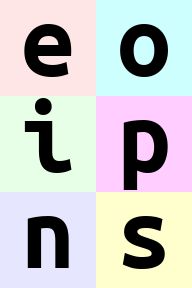

In [27]:
# Here we split the batch in two, each batch is laid out vertically, and the two vertical batches stacked horizontally
# such that we have a single image of height h * b2=3 and w * b1=2

rearrange(ims, "(b1 b2) h w c -> (b2 h) (b1 w) c", b1=2)

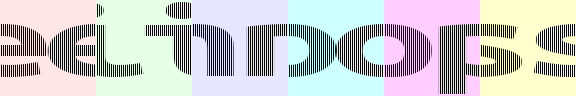

In [76]:
# Split the width image into two and swap the halves
rearrange(ims, "b h (w1 w2) c -> h (b w2 w1) c", w1=2)

In [73]:
# To better understand what's happening, let me try to arrange
# a simple 2D matrix

l = np.array([[1, 2, 3, 4, 5, 6], [11, 12, 13, 14, 15, 16]])

print("Original")
print(l)
print(l.shape)

print()
print("h (w1 w2) -> h w1 w2")
print(rearrange(l, "h (w1 w2) -> h w1 w2", w1=2))

print()
print("(h1 h2) (w1 w2) -> h1 h2 w1 w2")
print(rearrange(l, "(h1 h2) (w1 w2) -> h1 h2 w1 w2", h1=1, w1=2))

print()
print("h (w1 w2) -> h w2 w1")
# w2 w1 is basically a transpose of w1 w2
print(rearrange(l, "h (w1 w2) -> h w2 w1", w1=2))

print()
print("h (w1 w2) -> h (w2 w1)")
# What happens if we transpose without decomposing?
# Equivalent to flattening the transposed version
print(rearrange(l, "h (w1 w2) -> h (w2 w1)", w1=2))

print()
print("h (w1 w2) -> (h w1) w2")
print(rearrange(l, "h (w1 w2) -> (h w1) w2", w1=2))

print()
print("h (w1 w2) -> (h w2) w1")
# I found this to be tricky to understand.
# But a key hint is that w2 w1 is basically a transpose of w1 w2
# So we'll get 1 2 3 laid out vertically across rows instead of horizontally
# Rows will have pairs [1 4], [2 5], [3 6] which are from transposing w1 w2 in the first array h[0]
# Then h[1] will have [11, 14], [12, 15], [13, 16]
# But h and w2 are collapsed into a single dimension, so the two subarrays above are stacked int one
print(rearrange(l, "h (w1 w2) -> (h w2) w1", w1=2))


Original
[[ 1  2  3  4  5  6]
 [11 12 13 14 15 16]]
(2, 6)

h (w1 w2) -> h w1 w2
[[[ 1  2  3]
  [ 4  5  6]]

 [[11 12 13]
  [14 15 16]]]

(h1 h2) (w1 w2) -> h1 h2 w1 w2
[[[[ 1  2  3]
   [ 4  5  6]]

  [[11 12 13]
   [14 15 16]]]]

h (w1 w2) -> h w2 w1
[[[ 1  4]
  [ 2  5]
  [ 3  6]]

 [[11 14]
  [12 15]
  [13 16]]]

h (w1 w2) -> h (w2 w1)
[[ 1  4  2  5  3  6]
 [11 14 12 15 13 16]]

h (w1 w2) -> (h w1) w2
[[ 1  2  3]
 [ 4  5  6]
 [11 12 13]
 [14 15 16]]

h (w1 w2) -> (h w2) w1
[[ 1  4]
 [ 2  5]
 [ 3  6]
 [11 14]
 [12 15]
 [13 16]]


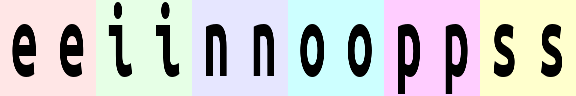

In [93]:
# I did not expect this to print each letter twice in half the width per letter
# We decompose the width in a 48x2 grid, that means
# 42 sub arrays of 2 pixels each. The 2 pixels in each array
# represent adjacent pixels in the image.
# If you take every other pixel of the image along the width, you'll get a similar
# image, but half the width. Adjacent pixels are very likely to have the same color
# in our simple images with only 2 colors, so half the image looks like the original but thinner.
# So when we swap w1 w1 to w2 w1, we get 2x48, 2 arrays where
# the first array gets every even pixel and the second array gets every odd pixel
# and the result is 2 almost-identical halves of the image side by side
# (the "halves" are not exactly the same since they are not the same pixels repeated, but adjacent pixels separated)
# Then we do this for each image in the batch and stack the results horizontally
rearrange(ims, "b h (w1 w2) c -> h (b w2 w1) c", w2=2)

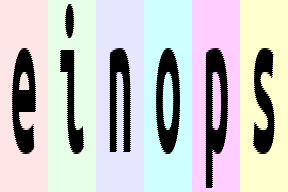

In [ ]:
# move part of width dimension to height.

# Now I can understand the "width-to-height" trick from the docs.
# For each image in the batch, we split the pixels in 2 groups (2x48)
# One with even pixels, the other with odd pixels
# Then instead of placing the groups side-by-side like in the previous example
# We arrange them vertically. So along the new height of each image h*2
# we place alternate over the adjacent pixels, so we get a thin but vertically
# stretched version of the image, then we repeat this across the batches stacked horizontally

# we should call this width-to-height as image width shrunk by 2 and height doubled.
# but all pixels are the same!
rearrange(ims, "b h (w1 w2) c -> (h w2) (b w1) c", w2=2)

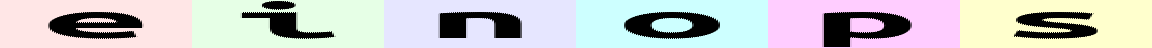

In [113]:
# Now can I try to create the height-to-width effect?
# What would that look like?
# We want to move part of height to width
# Shrink height by 2 and extend width by 2.
# Each image will be wider but shorter.
# We'll take every other pixel along the height axis and insert a column (width axis) that contains these pixels
# h1 h2 = 48 * 2, split height into 48 pairs where each pair has a top pixel and bottom pixel
# We'll remove the "bottom" pixels from below their top counter parts and move them next/to the right of their top counterparts
rearrange(ims, "b (h1 h2) w c -> h1 (b w h2) c", h2=2)

In [ ]:
# To better understand the height-to-width trick
# let's break it down with a simple example
# Let's assume the 2D array represents an image (maybe a grayscale image)
m = np.array([
    [0, 1, 2],
    [10, 11, 12],
    [20, 21, 22],
    [30, 31, 32],
    [40, 41, 42],
    [50, 51, 52],
    [60, 61, 62],
    [70, 71, 72]
])

print()
print("(h1 h2) w -> h1 h2 w")
print(rearrange(m, "(h1 h2) w -> h1 h2 w", h2=2))
# This breaks the height into pairs like
#     [[0 1 2] [10 11 12]]
# and [[20 21 22] [30 31 32]]
# In this case [0 1 2] and [20 21 22] represent arrays of "top pixels"
# and [10 11 12] and [30 31 32] are arrays of "bottom pixels"
# so to move part of height to width, we want to move each
# bottom pixel next to its corresponding top pixel, resulting in:
# [0 10 1 11 2 12] and [20 30 21 31 22 32]

print()
print("(h1 h2) w -> h2 h1 w")
print(rearrange(m, "(h1 h2) w -> h1 (w h2)", h2=2))


(h1 h2) w -> h1 h2 w
[[[ 0  1  2]
  [10 11 12]]

 [[20 21 22]
  [30 31 32]]

 [[40 41 42]
  [50 51 52]]

 [[60 61 62]
  [70 71 72]]]

(h1 h2) w -> h2 h1 w
[[ 0 10  1 11  2 12]
 [20 30 21 31 22 32]
 [40 50 41 51 42 52]
 [60 70 61 71 62 72]]


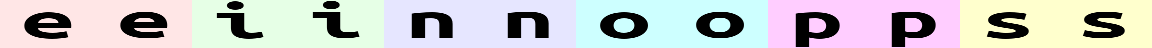

In [114]:
# We can also repeat letters by halving the height if we swap h2 and w
rearrange(ims, "b (h1 h2) w c -> h1 (b h2 w) c", h2=2)

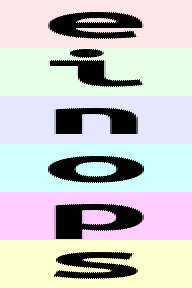

In [116]:
# And by moving b to the height dimension we can arrange them vertically
rearrange(ims, "b (h1 h2) w c -> (b h1) (w h2) c", h2=2)